# Dataframe Prep, Random Forest Modeling and Evaluation

-This notebook reads in the df_gen, df_slope, and df_ruby notebooks from Processing

-The filtering gets a little complicated here, heavy annotations for clarity. I'm creating both a RF for progeny, then mothers. 

-Output should be accuracy predicitions plots, model comparison plots, and pred vs actual correlation plots. 

In [1]:
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import os
import re
from collections import defaultdict
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
import shap
import matplotlib.cm as cm

# makes figures look better in Jupyter
sns.set_context('talk')
sns.set_style("ticks")
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

['/Users/Madison/Desktop/RFR_Test', '/Users/Madison/opt/anaconda3/envs/gmm/lib/python3.12/site-packages/cv2', '/Users/Madison/opt/anaconda3/envs/gmm/lib/python312.zip', '/Users/Madison/opt/anaconda3/envs/gmm/lib/python3.12', '/Users/Madison/opt/anaconda3/envs/gmm/lib/python3.12/lib-dynload', '', '/Users/Madison/opt/anaconda3/envs/gmm/lib/python3.12/site-packages', '__editable__.pyTrackMateXML-1.0.0.finder.__path_hook__']


## Filtering and Merging Dataframes

In [2]:
plot_output = '/Users/Madison/Desktop/RFR_Test'
#Read in all DIMM dfs
df_gen = pd.read_csv(os.path.join(plot_output, 'CellCycle_Stats.csv'))
df_slope = pd.read_csv(os.path.join(plot_output, 'Switch_Stats.csv'))
df_ruby = pd.read_csv(os.path.join(plot_output, 'mRuby_Stats.csv'))

In [3]:
#Filtering incomplete cycles
#removes incomplete cycles at the end of the expt
df_gen_no_end_cycle = df_gen[df_gen['end_time']!=1080] 

#Now remove cycles where cells fall out end of channel - defined as cycles that both don't have a following cycle and don't have valid cell IDs through the last time point
df_gen_no_end_cycle = df_gen_no_end_cycle.sort_values(by=['unique_ID', 'cell_id', 'cycle']) #sort
df_gen_no_end_cycle['next_cycle'] = df_gen_no_end_cycle.groupby(['unique_ID','cell_id'])['cycle'].shift(-1) #find following cycle
df_gen_no_lost_cells = df_gen_no_end_cycle[(df_gen_no_end_cycle['next_cycle'] == df_gen_no_end_cycle['cycle'] + 1) | (df_gen_no_end_cycle['last_valid_cell_time'] == 1080)].copy() #filter

#Remove first cycle as that's also incomplete
df_gen_filtered = df_gen_no_lost_cells[df_gen_no_lost_cells['start_time']!=0]

print(len(df_gen))
print(len(df_gen_no_end_cycle))
print(len(df_gen_no_lost_cells))
print(len(df_gen_filtered))
columns_with_nan = df_gen_filtered.isna().sum()
columns_with_nan = columns_with_nan[columns_with_nan > 0]
print(columns_with_nan)
#rows_with_nan = df_gen_filtered[df_gen_filtered.isnull().any(axis=1)]
#print(rows_with_nan)

10222
6112
4983
4727
end_length           1
total_growth         1
avg_elong_rate       1
next_cycle        2117
dtype: int64


In [4]:
#Merging into all stats dataframe
common_columns_1 = ['position', 'unique_ID', 'experiment', 'parent', 'cell_id','track']
gen_slope = df_gen_filtered.merge(df_slope, on=common_columns_1, how='left')
common_columns_2 = ['track', 'position', 'unique_ID', 'experiment', 'cell_id']
all_stats = gen_slope.merge(df_ruby, on=common_columns_2, how='left')
all_stats = all_stats[all_stats['category'] == 'switch']
#Adding a boolean for if the cycle is the one where the response happens
all_stats['response_cycle'] = (all_stats['start_time']<=all_stats['start_inc']) & (all_stats['start_inc']<all_stats['end_time'])
all_stats['start_inc'] = all_stats['start_inc'].astype(float)
all_stats['gfp_on'] = all_stats['gfp_on'].astype(float)
#all_stats.to_csv(plot_output +'all_stats_20250627.csv')

In [5]:
#Check all the lengths make sense with merging principles
print(len(df_gen_filtered))
print(len(gen_slope))
print(len(df_ruby))
print(len(all_stats))
all_stats.columns
columns_with_nan = all_stats.isna().sum()
columns_with_nan = columns_with_nan[columns_with_nan > 0]
print(columns_with_nan)

4727
4727
5239
2185
next_cycle          725
parent_start_inc    692
dtype: int64


In [6]:
#Looking up the first cycle duration and appending to the table (note this has to be found on the unfiltered df_gen)
#Getting the duration of that first cycle (ie where in cell cycle was the original mother before the transition)
#should be one value per unique ID
first_cycle_lookup = (
    df_gen[(df_gen['parent'] == 0) & (df_gen['cycle'] == 0)] # ensure only one per unique_ID
    .set_index('unique_ID')['cycle_duration']
)

all_stats['initial_cycle_duration'] = all_stats['unique_ID'].map(first_cycle_lookup)

In [7]:
#Split into mothers and daughters dfs
all_stats_prog = all_stats[all_stats['cell_id']!=1]

In [8]:
cols_to_keep_prog = ['unique_ID', 'channel_width', 'experiment', 'cell_id', 'cycle', 
                'category', 'cycle_duration', 'start_length', 'mean_ruby_lifetime', 
                'initial_cycle_duration', 'time_of_min_slope_ruby', 'max_ruby', 
                'max_ruby_time', 'end_length', 'avg_elong_rate', 'total_growth', 
                'start_inc', 'parent_start_inc', 'y_pos_start_inc', 'y_pos_appearance', 
               'min_slope_ruby', 'response_cycle']
all_stats_prog_rc = all_stats_prog[cols_to_keep_prog]
all_stats_prog_rc

,unique_ID,channel_width,experiment,cell_id,cycle,category,cycle_duration,start_length,mean_ruby_lifetime,initial_cycle_duration,...,max_ruby_time,end_length,avg_elong_rate,total_growth,start_inc,parent_start_inc,y_pos_start_inc,y_pos_appearance,min_slope_ruby,response_cycle
6,20240809__XY02_crop2__Track_20,1.3,20240809,2,0,switch,465,1.482228,8.464784,535,...,540.0,4.687216,0.006892,3.204988,550.0,550.0,35.689655,35.672413,-0.045544,True
9,20240809__XY02_crop3__Track_8,1.3,20240809,2,0,switch,250,1.482228,8.870182,355,...,1080.0,3.034881,0.006211,1.552653,390.0,385.0,36.000000,33.900000,-0.046889,True
21,20240809__XY03_crop2__Track_0,1.3,20240809,2,0,switch,190,1.400143,9.144921,225,...,230.0,2.612967,0.006383,1.212825,240.0,240.0,38.095238,36.516130,-0.056960,True
22,20240809__XY03_crop2__Track_0,1.3,20240809,2,1,switch,325,1.453444,9.144921,225,...,230.0,3.314363,0.005726,1.860918,240.0,240.0,38.095238,36.516130,-0.056960,False
31,20240809__XY04_crop1__Track_14,1.3,20240809,2,0,switch,170,2.018143,8.923444,220,...,235.0,3.260383,0.007307,1.242241,325.0,330.0,49.027780,41.833332,-0.041630,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4715,20241028__XY29_crop6__Track_3,1.2,20241028,6,1,switch,225,1.768191,8.812297,285,...,500.0,3.291337,0.006770,1.523146,630.0,630.0,54.329544,53.055046,-0.039643,True
4717,20241028__XY29_crop6__Track_3,1.2,20241028,8,0,switch,245,1.453444,8.625902,285,...,630.0,3.015327,0.006375,1.561883,710.0,780.0,190.207320,154.400000,-0.040268,True
4718,20241028__XY29_crop6__Track_3,1.2,20241028,9,0,switch,230,1.521611,8.749192,285,...,835.0,3.144280,0.007055,1.622670,740.0,680.0,148.674420,117.639340,-0.033366,True
4719,20241028__XY29_crop6__Track_3,1.2,20241028,10,0,switch,210,1.453444,8.915859,285,...,775.0,2.779082,0.006313,1.325638,835.0,965.0,147.720340,96.357140,-0.028858,True


In [9]:
#get numbers out of arrays if that is an issue here
def unwrap_scalar_array(x):
    if isinstance(x, np.ndarray) and x.size == 1:
        return x.item()
    return x
for column in all_stats_prog_rc:
    all_stats_prog_rc[column] = all_stats_prog_rc[column].apply(unwrap_scalar_array)

/var/folders/46/k335xc3d451dkz01yv9q72sc0000gr/T/ipykernel_76147/3948174683.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_stats_prog_rc[column] = all_stats_prog_rc[column].apply(unwrap_scalar_array)


In [10]:
#Now find variables that are on a per cycle basis and get the averages of them, retain ones that are the same for every cycle
#should have 1 row per cell now
for col in all_stats_prog_rc.columns:
    unhashable = all_stats_prog_rc[col].apply(lambda x: isinstance(x, (list, np.ndarray))).any()
    if unhashable:
        print(f"Column '{col}' contains unhashable types like list or ndarray.")

grouped = all_stats_prog_rc.groupby(['unique_ID', 'cell_id'])

# Identify constant variables (same value across all cycles in each group)
constant_vars = []
for col in all_stats_prog_rc.columns:
    if col not in ['unique_ID', 'cell_id', 'cycle']:
        nunique_per_group = grouped[col].nunique()
        if nunique_per_group.max() == 1:
            constant_vars.append(col)
print("constant variables, keeping one:",constant_vars)

# Identify varying variables (change across cycles)
varying_vars = [col for col in all_stats_prog_rc.columns
                if col not in ['unique_ID', 'cell_id', 'cycle']
                and col not in constant_vars]
print("cycle based variables, averaging:",varying_vars)

# Aggregate
constant_df = grouped[constant_vars].first().reset_index()
varying_df = grouped[varying_vars].mean().reset_index()

# Rename varying columns
varying_df = varying_df.rename(columns={col: f"{col}_avg" for col in varying_vars})

# Merge
avg_stats_prog = pd.merge(constant_df, varying_df, on=['unique_ID', 'cell_id'])
avg_stats_prog = avg_stats_prog.drop('response_cycle_avg', axis=1)

constant variables, keeping one: ['channel_width', 'experiment', 'category', 'mean_ruby_lifetime', 'initial_cycle_duration', 'time_of_min_slope_ruby', 'max_ruby', 'max_ruby_time', 'start_inc', 'parent_start_inc', 'y_pos_start_inc', 'y_pos_appearance', 'min_slope_ruby']
cycle based variables, averaging: ['cycle_duration', 'start_length', 'end_length', 'avg_elong_rate', 'total_growth', 'response_cycle']


In [11]:
#Now go back and get the response cycle only in a dataframe, then merge onto the averages. 
#we lose cells here that respond in the first or last incomplete cycles because they've already been filtered out of df_gen
res_cycle_prog_df = all_stats_prog[all_stats_prog['response_cycle']==True]
for column in res_cycle_prog_df:
    res_cycle_prog_df[column] = res_cycle_prog_df[column].apply(unwrap_scalar_array)
common_columns_4 = list(set(avg_stats_prog.columns) & set(res_cycle_prog_df.columns))
print("Common columns:", common_columns_4)

Common columns: ['start_inc', 'min_slope_ruby', 'experiment', 'category', 'time_of_min_slope_ruby', 'max_ruby', 'unique_ID', 'y_pos_appearance', 'max_ruby_time', 'initial_cycle_duration', 'parent_start_inc', 'y_pos_start_inc', 'mean_ruby_lifetime', 'channel_width', 'cell_id']


/var/folders/46/k335xc3d451dkz01yv9q72sc0000gr/T/ipykernel_76147/404004527.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_cycle_prog_df[column] = res_cycle_prog_df[column].apply(unwrap_scalar_array)


In [12]:
##For this merge we're merging onto the res_cycle_df because it has fewer cells 
final_forest_df_prog = pd.merge(res_cycle_prog_df, avg_stats_prog, on = common_columns_4,  how='left')
print(len(final_forest_df_prog))
print(final_forest_df_prog.columns)

591
Index(['Unnamed: 0_x', 'unique_ID', 'experiment', 'channel_width',
       'last_valid_cell_time', 'first_valid_cell_time', 'position', 'track',
       'cell_id', 'parent', 'cycle', 'start_time', 'start_length', 'end_time',
       'end_length', 'cycle_duration', 'total_growth', 'avg_elong_rate',
       'next_cycle', 'Unnamed: 0_y', 'max_slope', 'appearance_time',
       'time_of_max_slope', 'start_inc', 'start_idx_var_value',
       'y_pos_start_inc', 'y_pos_appearance', 'gfp_on', 'end_inc',
       'end_idx_var_value', 'born_on', 'lifetime_x', 'slope_th', 'max_gfp',
       'max_gfp_time', 'min_post_max', 'min_time_post_max', 'switch_like',
       'becomes_positive', 'duration', 'magnitude_inc', 'category',
       'long_enough_time', 'parent_start_inc', 'Unnamed: 0', 'min_slope_ruby',
       'time_of_min_slope_ruby', 'lifetime_y', 'mean_ruby_lifetime',
       'max_ruby', 'max_ruby_time', 'response_cycle', 'initial_cycle_duration',
       'cycle_duration_avg', 'start_length_avg', 'end

In [14]:
nan_counts_per_column = final_forest_df_prog.isna().sum()
print(nan_counts_per_column)

Unnamed: 0_x                0
unique_ID                   0
experiment                  0
channel_width               0
last_valid_cell_time        0
first_valid_cell_time       0
position                    0
track                       0
cell_id                     0
parent                      0
cycle                       0
start_time                  0
start_length                0
end_time                    0
end_length                  0
cycle_duration              0
total_growth                0
avg_elong_rate              0
next_cycle                130
Unnamed: 0_y                0
max_slope                   0
appearance_time             0
time_of_max_slope           0
start_inc                   0
start_idx_var_value         0
y_pos_start_inc             0
y_pos_appearance            0
gfp_on                      0
end_inc                     0
end_idx_var_value           0
born_on                     0
lifetime_x                  0
slope_th                    0
max_gfp   

## Random Forest Regressor and Evaluation - Progeny
Steps:

1. Define train and test data

2. Remove any extraneous columns

3. Define input and output columns

4. Random Forest Regressor

5. SHAP values and prediction accuracy

In [15]:
#Import model parameter spreadsheet to get all the options
model_params = pd.read_excel(plot_output+'/model_params.xlsx')
model_params = model_params.set_index('Model')

#Make a dictionary of parameter lists to use
params_to_use = {model: list(row.index[row.astype(bool)])  # make sure row is True/False
                 for model, row in model_params.iterrows()}


#Make a dictionary of finalized dataframes for use in the RFR
model_dfs = {}
for model, params in params_to_use.items():
    model_dfs[model] = final_forest_df_prog[params]
    print(len(model_dfs[model]))

591
591
591
591
591
591
591
591
591
591
591
591
591
591


In [16]:
clean_model_dfs = {}
for model, df in model_dfs.items():
    nan_counts_per_column = df.isna().sum()
    print(nan_counts_per_column)
    clean_model_dfs[model] = df.dropna()

experiment                0
channel_width             0
cycle_duration            0
cycle_duration_avg        0
start_length              0
start_length_avg          0
end_length                0
end_length_avg            0
total_growth              0
total_growth_avg          0
avg_elong_rate            0
avg_elong_rate_avg        0
max_ruby                  0
mean_ruby_lifetime        0
min_slope_ruby            0
time_of_min_slope_ruby    0
parent_start_inc          8
y_pos_appearance          0
y_pos_start_inc           0
max_ruby_time             0
start_inc                 0
dtype: int64
experiment                0
channel_width             0
cycle_duration            0
cycle_duration_avg        0
start_length              0
start_length_avg          0
end_length                0
end_length_avg            0
total_growth              0
total_growth_avg          0
avg_elong_rate            0
avg_elong_rate_avg        0
max_ruby                  0
mean_ruby_lifetime        0
min_slo

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#Steps here are to define the training and test data, run the random forest, and then collect predictive metrics
results = []
SHAP_summary = {}
for model, df in clean_model_dfs.items():
    print(f"making test and train data for {model}")
    train,test=train_test_split(df, test_size=0.3, random_state=0)
    X_train = train.drop(['start_inc'], axis=1)
    Y_train = train['start_inc']
    X_test  = test.drop(['start_inc'], axis=1)
    Y_test  = test['start_inc']
    print(f"running random forest for {model}")
    random_forest = RandomForestRegressor(n_estimators=100)
    random_forest.fit(X_train, Y_train)
    random_forest_preds = random_forest.predict(X_test)
    
    #Calculating some evaluation metrics - add as needed
    MSE = mean_squared_error(Y_test, random_forest_preds)
    MAE = mean_absolute_error(Y_test, random_forest_preds)
    R2 = r2_score(Y_test, random_forest_preds)
    accuracy_df_mothers = pd.DataFrame({'Experimental': Y_test, 'Predicted': random_forest_preds})
    accuracy_df_mothers['individual_acc']= abs((accuracy_df_mothers['Predicted']-accuracy_df_mothers['Experimental'])/accuracy_df_mothers['Experimental'])
    accuracy = 1-(1/len(accuracy_df_mothers) * accuracy_df_mothers['individual_acc'].sum())

    #Plotting and saving each model output in a pdf, lots of hard coding for plot settings in here, change if needed. 
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=Y_test, y=random_forest_preds, s=50, edgecolor="white")
    z = np.polyfit(Y_test, random_forest_preds, 1)  # Linear trendline (degree 1)
    p = np.poly1d(z)
    plt.plot(Y_test, p(Y_test), "lightsteelblue")
    x = np.array([100, 850])
    y = 1 * x + 0
    plt.plot(x, y, "black")
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.ylim(100, 850)
    plt.xlim(100,850)
    save_path = os.path.join(plot_output+'/RandomForestNew')
    plt.savefig(save_path, f"{model}_actvspred.pdf"), bbox_inches='tight')
    plt.close() 

    #Calculating feature importances 
    explainer = shap.TreeExplainer(random_forest)
    shap_values = explainer(X_test)
    n_features = X_test.shape[1]
    cmap = plt.colormaps["viridis"].resampled(n_features)
    color_list = [cmap(i) for i in range(n_features)]
    #Create the summary plot for each model
    shap.summary_plot(shap_values, X_test, cmap='viridis', show=False)
    plt.savefig(os.path.join(plot_output+'/RandomForestNew', f"{model}_shap_swarm.pdf"), bbox_inches='tight')
    plt.close()
    #Calculate the mean abs. value of each parameter for each model
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    # wrap in a pandas series for readability
    mean_abs_shap_df = pd.Series(mean_abs_shap, index=X_train.columns, name="mean_abs_shap")

    # sort descending
    SHAP_summary[model]= mean_abs_shap_df.sort_values(ascending=False)

    
    #Putting eval metrics in df for storage
    results.append({
        'model': model,
        'MSE': MSE,
        'MAE': MAE,
        'R2': R2, 
        'accuracy':accuracy
    })



prog_model_summary_df = pd.DataFrame(results)
SHAP_abs_value = pd.concat(SHAP_summary, axis=1).T.reset_index().rename(columns={'index': 'model'})
#Every time these models are remade you can expect slight differences. Model output used in the final plot can be found in the 'DIMM Summaries' folder

making test and train data for all_params
running random forest for all_params
making test and train data for A
running random forest for A
making test and train data for B
running random forest for B
making test and train data for C
running random forest for C
making test and train data for D
running random forest for D
making test and train data for no_time_params
running random forest for no_time_params
making test and train data for direct_growth_params
running random forest for direct_growth_params
making test and train data for response_cycle_params
running random forest for response_cycle_params
making test and train data for constant_avg_params
running random forest for constant_avg_params
making test and train data for time_param_only
running random forest for time_param_only
making test and train data for one_time_param
running random forest for one_time_param
making test and train data for irrelavant_time_param
running random forest for irrelavant_time_param
making test and 

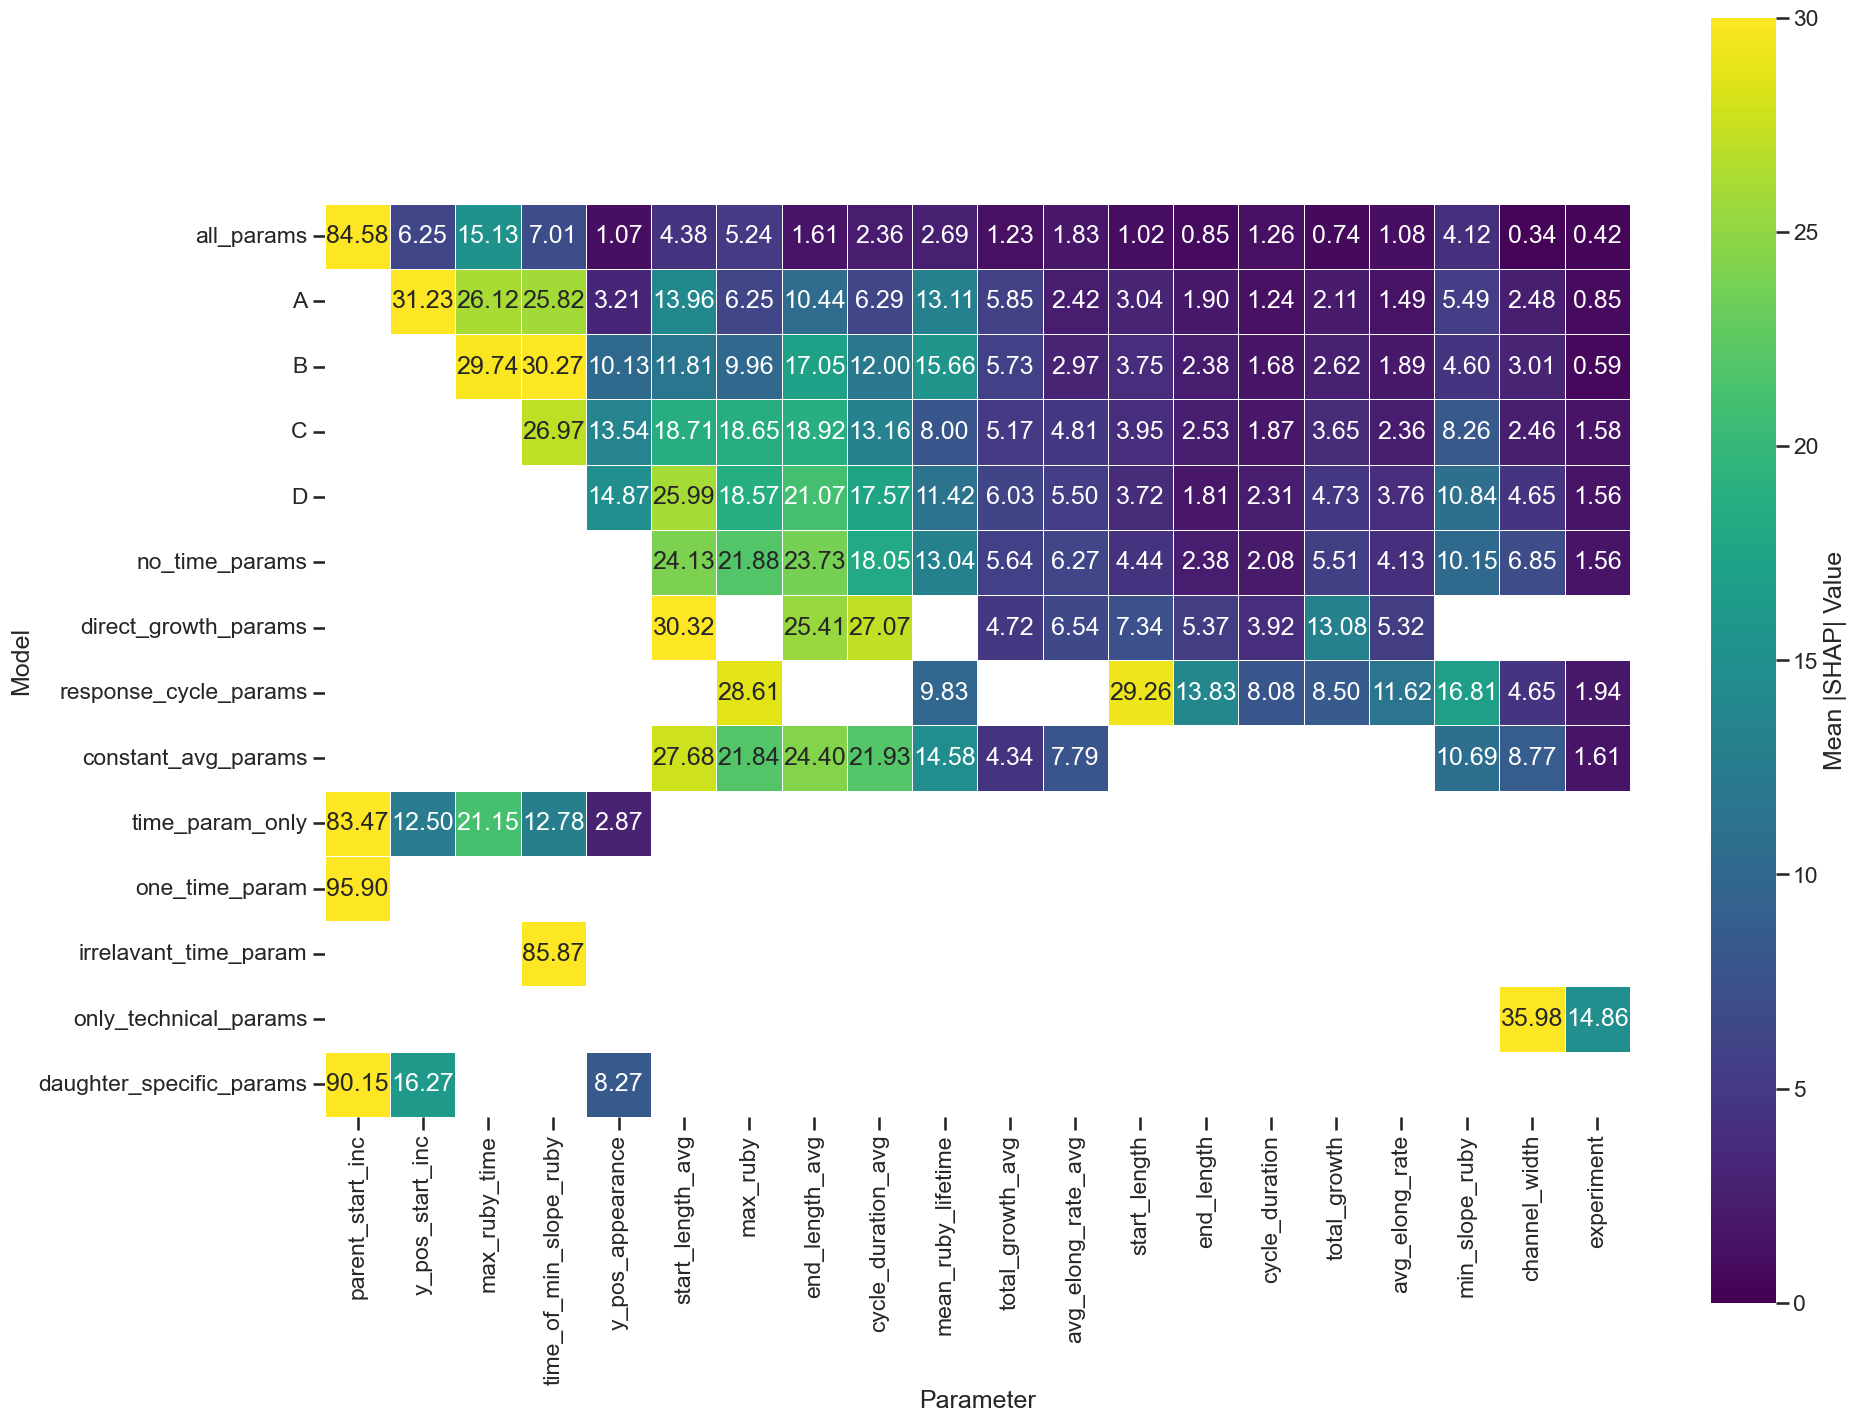

In [19]:
# Set 'model' as the index if it isn't already
output = '/Volumes/salmonella/users/madison/2024_DIMM_MultirepAnalysis/LineagePlotting/Final_Plots/RandomForestNew'
#manually set parameter order based on categories
desired_order = ['parent_start_inc', 'y_pos_start_inc', 'max_ruby_time', 'time_of_min_slope_ruby', 'y_pos_appearance', 
                 'start_length_avg', 'max_ruby', 'end_length_avg', 'cycle_duration_avg', 'mean_ruby_lifetime', 'total_growth_avg', 'avg_elong_rate_avg',
                 'start_length', 'end_length', 'cycle_duration', 'total_growth', 'avg_elong_rate',
                 'min_slope_ruby', 'channel_width', 'experiment']
                 
heatmap_df = SHAP_abs_value.set_index('model')
# Reorder columns
heatmap_df = heatmap_df[desired_order]


plt.figure(figsize=(20, 15))
sns.heatmap(
    heatmap_df.astype(float),   # make sure all numeric
    cmap='viridis', vmin = 0, vmax = 30,  #Note that max was manually set so that outlier doesn't dominate plot - yellows do not extend to highest range.          
    annot=True,                 
    fmt=".2f",                  
    linewidths=0.5,   
    square = True,# thin white lines between cells
    cbar_kws={'label': 'Mean |SHAP| Value'}  # colorbar label
)

plt.xlabel('Parameter')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(output+'/daughters_SHAP_map.pdf')


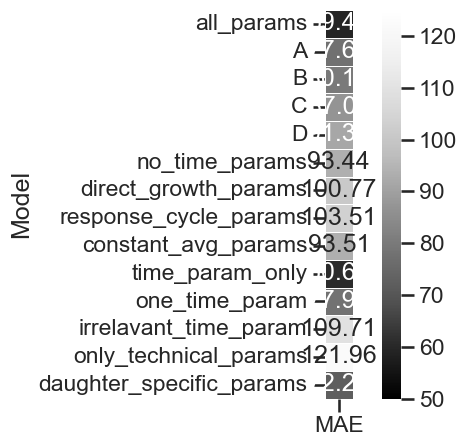

In [20]:
#Make a heatmap of summary accuracy metric of interest
columns_to_drop = ['accuracy', 'MSE', 'R2']
acc_only = prog_model_summary_df.drop(columns=columns_to_drop, axis=1)
heatmap_df = acc_only.set_index('model')

sns.heatmap(
    heatmap_df.astype(float),   # make sure all numeric
    cmap='Greys_r', vmin = 50, vmax = 125,           
    annot=True,                 
    fmt=".2f",  
    square=True,                #note this is kept as square such that this can be aligned with the SHAP heatmap, alignment and changing text size was done manually
    linewidths=0.5,             # thin white lines between cells
 # colorbar label
)

plt.ylabel('Model')
plt.tight_layout()
plt.savefig(output+'/MAE_heat.pdf')